# GreenPEFT Surrogate Dataset — Research Notebook

**Purpose:** Exploratory data analysis, data-quality assessment, statistical comparison of PEFT methods, and baseline modelling on the GreenPEFT surrogate dataset.

**Citation:**
```bibtex
@misc{ashraful_islam_tanzil_2026,
  title={greenpeft-surrogate-data},
  url={https://www.kaggle.com/dsv/20178095},
  DOI={10.34740/KAGGLE/DSV/20178095},
  publisher={Kaggle},
  author={Ashraful Islam Tanzil},
  year={2026}
}
```

---
**Notebook outline**
1. Setup & imports
2. Load data
3. Schema & data dictionary
4. Data quality audit (`is_empirical`, `analysis_role`, `data_quality_flag`)
5. Exploratory data analysis (methods, scales, metrics)
6. Comparative analysis: PEFT vs full-FT
7. Efficiency frontiers (accuracy vs energy, accuracy vs memory)
8. Baseline predictive model (energy / accuracy)
9. Summary & next steps

In [4]:
# ============================================================
# 1. SETUP & IMPORTS
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('pandas', pd.__version__)
print('numpy ', np.__version__)

pandas 2.3.3
numpy  2.0.2


In [5]:
# ============================================================
# 2. LOAD DATA
# ============================================================
import os, glob

DATA_PATH = (
    "/kaggle/input/datasets/ashrafulislamtanzil/"
    "greenpeft-surrogate-data/greenpeft_ml_ready_dataset.csv"
)

# Safety net: fall back to auto-discovery if the path ever changes
if not os.path.exists(DATA_PATH):
    matches = glob.glob(
        "/kaggle/input/**/greenpeft_ml_ready_dataset.csv", recursive=True
    )
    if matches:
        DATA_PATH = matches[0]
    else:
        raise FileNotFoundError(
            "Could not find greenpeft_ml_ready_dataset.csv under /kaggle/input. "
            "Re-attach the 'greenpeft-surrogate-data' dataset from the right sidebar."
        )

print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(3)

Loading: /kaggle/input/datasets/ashrafulislamtanzil/greenpeft-surrogate-data/greenpeft_ml_ready_dataset.csv
Shape: (477, 46)


,run_id,method,backbone,family,params_b,rank,quant_bits,is_adapter_method,gpu_total_gb,status,fits,trainable_param_pct,accuracy,peak_gpu_memory_gb,energy_kwh,carbon_kgco2eq,wall_clock_seconds,carbon_derived_kg,log_params_b,params_x_bits,log_params_x_bits,weight_bytes_gb,trainable_frac,trainable_params_b,optimizer_state_gb,gradient_gb,memory_proxy_gb,vram_pressure,is_quantized,adapter_capacity,log1p_rank,is_full_finetune,energy_per_acc_point,vram_efficiency,throughput_proxy,has_adapter_config,gpu_budget_known,is_seed_outlier,config_id,measurement_pass,energy_measurement_valid,analysis_role,split_reason,data_source,is_empirical,data_quality_flag
0,full_ft_tiny_classification_seed13,full_ft,tiny,qwen,0.5,0.0,32,0.0,15.6,ok,1,1.0,0.9117,11.462,0.002394,0.001556,132.28,0.001556,-0.30103,16.0,1.20412,2.0,0.01,0.005,0.04,0.02,2.06,0.132051,0,0.0,0.0,1,0.002626,0.079541,0.007560,1,1,0,full_ft_tiny_classification_seed13,original,1,surrogate_train,measured single-GPU PEFT fine-tuning run,greenpeft_kaggle_t4_benchmark,1,measured_single_gpu_peft_finetuning_run
1,full_ft_tiny_classification_seed2024,full_ft,tiny,qwen,0.5,0.0,32,0.0,15.6,ok,1,1.0,0.8991,11.439,0.002409,0.001566,132.95,0.001566,-0.30103,16.0,1.20412,2.0,0.01,0.005,0.04,0.02,2.06,0.132051,0,0.0,0.0,1,0.002680,0.078600,0.007522,1,1,0,full_ft_tiny_classification_seed2024,original,1,surrogate_train,measured single-GPU PEFT fine-tuning run,greenpeft_kaggle_t4_benchmark,1,measured_single_gpu_peft_finetuning_run
2,full_ft_tiny_classification_seed42,full_ft,tiny,qwen,0.5,0.0,32,0.0,15.6,ok,1,1.0,0.9048,11.414,0.002380,0.001547,131.62,0.001547,-0.30103,16.0,1.20412,2.0,0.01,0.005,0.04,0.02,2.06,0.132051,0,0.0,0.0,1,0.002630,0.079271,0.007598,1,1,0,full_ft_tiny_classification_seed42,original,1,surrogate_train,measured single-GPU PEFT fine-tuning run,greenpeft_kaggle_t4_benchmark,1,measured_single_gpu_peft_finetuning_run


In [6]:
# ============================================================
# 3. SCHEMA & DATA DICTIONARY
# ============================================================
schema = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_nonnull': df.notna().sum(),
    'n_null': df.isna().sum(),
    'pct_null': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=True)
})
schema

,dtype,n_nonnull,n_null,pct_null,n_unique
run_id,object,477,0,0.00,477
method,object,477,0,0.00,7
backbone,object,477,0,0.00,6
family,object,477,0,0.00,6
params_b,float64,477,0,0.00,47
rank,float64,477,0,0.00,2
quant_bits,int64,477,0,0.00,3
is_adapter_method,float64,477,0,0.00,2
gpu_total_gb,float64,82,395,82.81,1
status,object,477,0,0.00,1


### Key columns

| Column | Meaning |
|---|---|
| `run_id` | Unique experiment identifier |
| `method` | PEFT / training method (`full_ft`, `lisa`, `lora`, `lora_fa`, `qlora`, `none_inference_only`, `pretrain_full_scratch`) |
| `backbone` | Size bucket (`tiny`, `small`, `medium`, `large`, `xlarge`, `huge`) |
| `family` | Model family (`qwen`, `llama`, `other`, `mistral`, `gemini`, `falcon`, `gemma`) |
| `params_b` | Parameter count in billions |
| `rank`, `quant_bits` | LoRA rank and quantisation width |
| `is_adapter_method` | 1 if LoRA-style adapter, else 0 |
| `accuracy` | Downstream task accuracy |
| `peak_gpu_memory_gb` | Peak GPU memory |
| `energy_kwh` | Training energy |
| `carbon_kgco2eq` | Carbon footprint |
| `wall_clock_seconds` | Training time |
| `analysis_role` | `surrogate_train`, `scale_reference`, `context_only` |
| `is_empirical` | 1 if measured, 0 if derived context |
| `data_quality_flag` | Free-text provenance note |

**Important:** The dataset mixes three provenance classes. Always filter by `analysis_role` before comparing energy/accuracy.

In [7]:
# ============================================================
# 4. DATA-QUALITY AUDIT
# ============================================================
print('analysis_role counts:')
print(df['analysis_role'].value_counts(), '\n')

print('is_empirical counts:')
print(df['is_empirical'].value_counts(), '\n')

print('data_quality_flag counts:')
print(df['data_quality_flag'].value_counts(), '\n')

print('measurement_pass counts:')
print(df['measurement_pass'].value_counts(), '\n')

print('energy_measurement_valid counts:')
print(df['energy_measurement_valid'].value_counts())

analysis_role counts:
analysis_role
scale_reference    369
surrogate_train     82
context_only        26
Name: count, dtype: int64 

is_empirical counts:
is_empirical
1    467
0     10
Name: count, dtype: int64 

data_quality_flag counts:
data_quality_flag
inference_only_no_finetuning_method_applied                                                                            369
measured_single_gpu_peft_finetuning_run                                                                                 82
PRETRAINING_FROM_SCRATCH_NOT_FINETUNING -- energy/time are 9+ orders of magnitude larger than single-GPU PEFT runs.     26
Name: count, dtype: int64 

measurement_pass counts:
measurement_pass
single        395
original       41
remeasured     41
Name: count, dtype: int64 

energy_measurement_valid counts:
energy_measurement_valid
0    420
1     57
Name: count, dtype: int64


In [8]:
# Split the dataset by provenance so downstream analyses stay clean.
peft_runs = df[df['analysis_role'] == 'surrogate_train'].copy()
scale_ref = df[df['analysis_role'] == 'scale_reference'].copy()
context    = df[df['analysis_role'] == 'context_only'].copy()

print(f'surrogate_train : {peft_runs.shape}')
print(f'scale_reference : {scale_ref.shape}')
print(f'context_only    : {context.shape}')

# Focus of this notebook: empirical PEFT runs
peft_runs = peft_runs[peft_runs['is_empirical'] == 1].reset_index(drop=True)
print('\nEmpirical PEFT runs only:', peft_runs.shape)

surrogate_train : (82, 46)
scale_reference : (369, 46)
context_only    : (26, 46)

Empirical PEFT runs only: (82, 46)


## 5. Exploratory Data Analysis (on empirical PEFT runs)

In [9]:
# Method x backbone crosstab
ct = pd.crosstab(peft_runs['method'], peft_runs['backbone'])
ct

backbone,large,medium,small,tiny
method,,,,
full_ft,0,0,0,6
lisa,0,6,6,6
lora,0,4,6,6
lora_fa,0,6,6,6
qlora,6,6,6,6


In [10]:
# Summary statistics per method
metrics = ['accuracy', 'peak_gpu_memory_gb', 'energy_kwh',
           'wall_clock_seconds', 'carbon_kgco2eq', 'trainable_param_pct']

summary = (peft_runs
           .groupby('method')[metrics]
           .agg(['mean', 'std', 'count']))
summary.round(6)

accuracy                 peak_gpu_memory_gb                 energy_kwh                 wall_clock_seconds                  carbon_kgco2eq                 trainable_param_pct                
             mean       std count               mean       std count       mean       std count               mean        std count           mean       std count                mean       std count
method                                                                                                                                                                                                
full_ft  0.905200  0.005643     6          11.126500  0.344498     6   0.001388  0.001103     6         135.676667   3.757449     6       0.000902  0.000717     6            1.000000  0.000000     6
lisa     0.915000  0.024599    18          10.399611  4.280436    18   0.001134  0.000932    18         110.570000  28.669203    18       0.000737  0.000606    18            0.836638  0.089585    18
lora     0.934912  0.014346    16           8.156312  3.332499    16   0.001002  0.000743    16         114.818750  11.188110    16       0.000651  0.000483    16            0.003968  0.000686    16
lora_fa  0.927878  0.011899    18           8.294167  3.424625    18   0.001025  0.000769    18         111.764444  11.067830    18       0.000666  0.000500    18            0.001398  0.000261    18
qlora    0.935400  0.014986    24           5.069958  2.114526    24   0.002100  0.001855    24         217.482917  71.771295    24       0.001365  0.001206    24            0.006040  0.001555    24

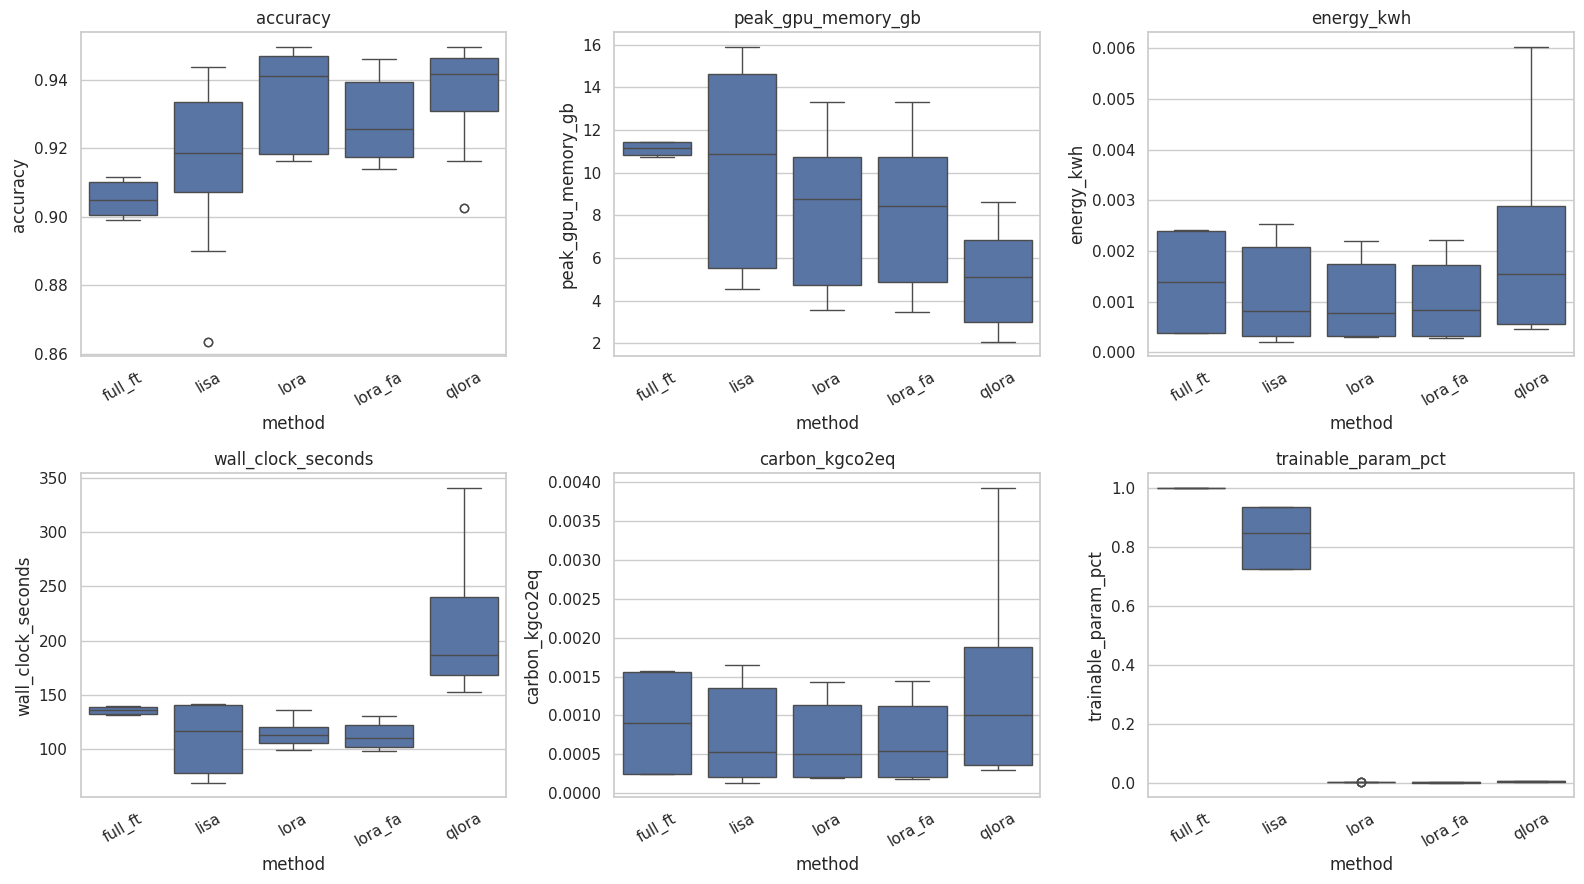

In [11]:
# Distribution plots for the key metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics_to_plot = ['accuracy', 'peak_gpu_memory_gb', 'energy_kwh',
                   'wall_clock_seconds', 'carbon_kgco2eq', 'trainable_param_pct']

for ax, m in zip(axes.ravel(), metrics_to_plot):
    sns.boxplot(data=peft_runs, x='method', y=m, ax=ax)
    ax.set_title(m)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

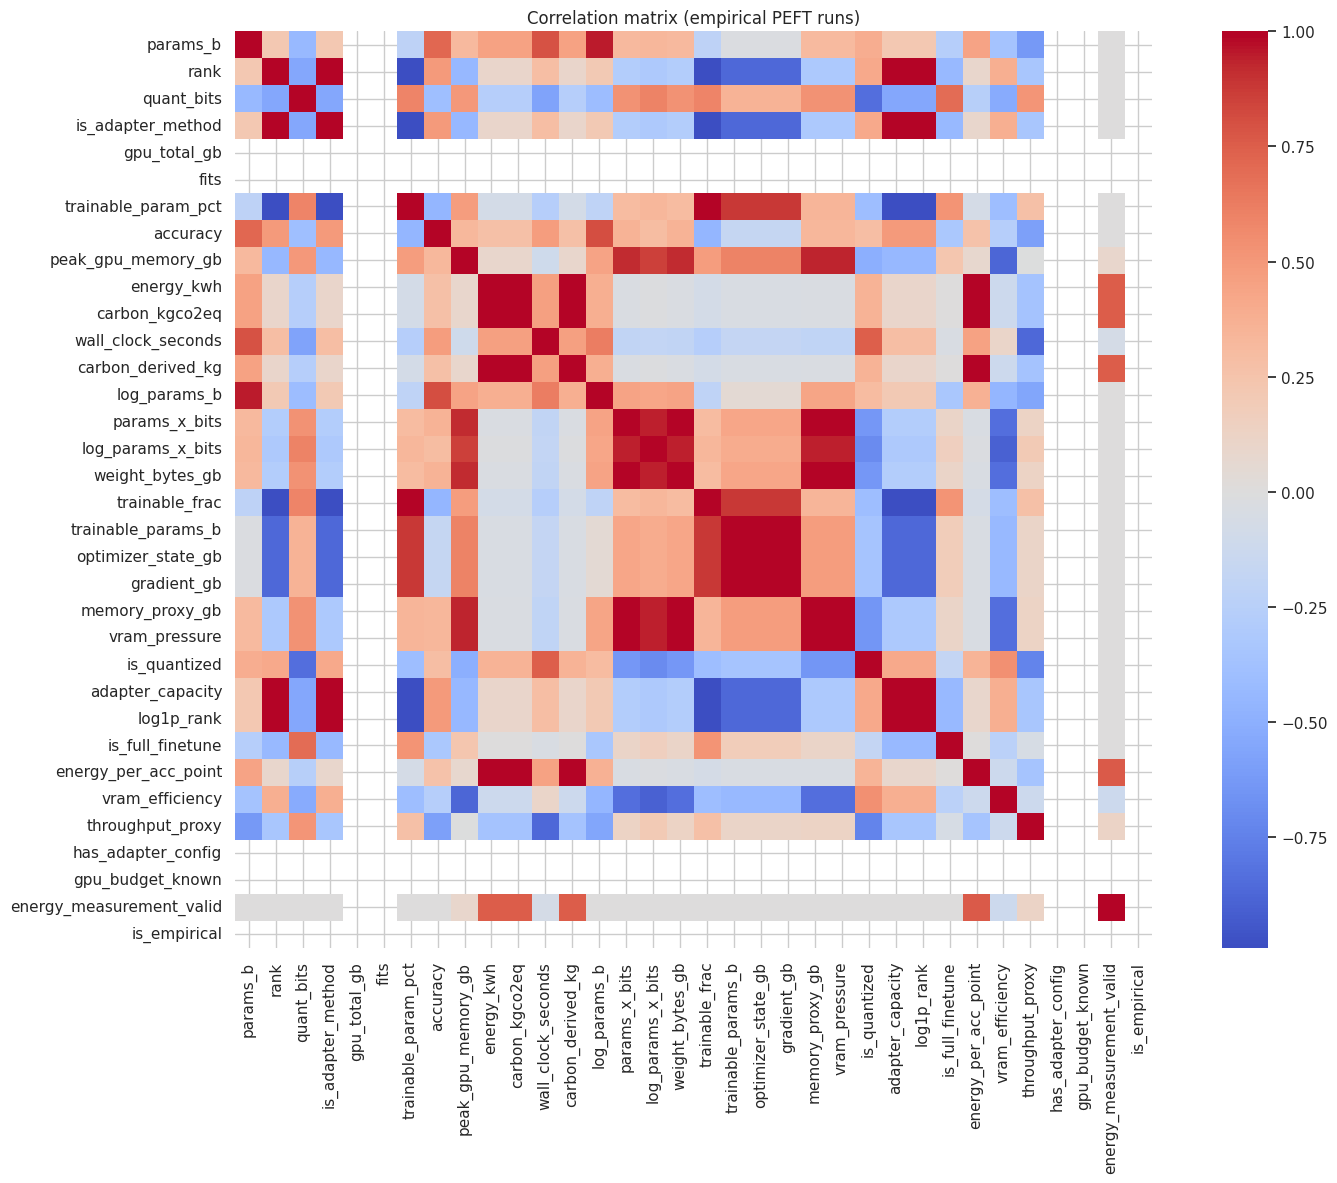

Top correlations with accuracy:
accuracy              1.000000
log_params_b          0.812616
params_b              0.717358
rank                  0.490926
is_adapter_method     0.490926
adapter_capacity      0.490926
log1p_rank            0.490926
wall_clock_seconds    0.475225
params_x_bits         0.356213
weight_bytes_gb       0.356213
vram_pressure         0.338702
memory_proxy_gb       0.338702
Name: accuracy, dtype: float64

Top correlations with energy_kwh:
energy_kwh                  1.000000
carbon_derived_kg           1.000000
carbon_kgco2eq              1.000000
energy_per_acc_point        0.999728
energy_measurement_valid    0.753778
wall_clock_seconds          0.457646
params_b                    0.454450
log_params_b                0.381342
is_quantized                0.356120
accuracy                    0.270338
adapter_capacity            0.093722
log1p_rank                  0.093722
Name: energy_kwh, dtype: float64


In [12]:
# Correlation matrix of numeric columns
num_cols = peft_runs.select_dtypes(include=[np.number]).columns.tolist()
# Drop leakage-prone / redundant identifiers
drop_from_corr = ['is_seed_outlier', 'config_id']
num_cols = [c for c in num_cols if c not in drop_from_corr]

corr = peft_runs[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Correlation matrix (empirical PEFT runs)')
plt.tight_layout()
plt.show()

# Show the strongest correlations with accuracy and energy
print('Top correlations with accuracy:')
print(corr['accuracy'].sort_values(ascending=False).head(12))
print()
print('Top correlations with energy_kwh:')
print(corr['energy_kwh'].sort_values(ascending=False).head(12))

## 6. Comparative Analysis — PEFT vs Full Fine-Tuning

In [13]:
# Aggregate across seeds for each (method, backbone) configuration.
agg = (peft_runs
       .groupby(['method', 'backbone', 'family', 'params_b'])
       .agg(accuracy_mean=('accuracy', 'mean'),
            accuracy_std=('accuracy', 'std'),
            energy_mean=('energy_kwh', 'mean'),
            mem_mean=('peak_gpu_memory_gb', 'mean'),
            time_mean=('wall_clock_seconds', 'mean'),
            n=('run_id', 'count'))
       .reset_index())
agg.round(6)

,method,backbone,family,params_b,accuracy_mean,accuracy_std,energy_mean,mem_mean,time_mean,n
0,full_ft,tiny,qwen,0.5,0.905200,0.005643,0.001388,11.126500,135.676667,6
1,lisa,medium,qwen,1.5,0.938067,0.004694,0.001459,15.209833,140.953333,6
2,lisa,small,llama,1.1,0.920100,0.005273,0.001206,10.877333,116.921667,6
3,lisa,tiny,qwen,0.5,0.886833,0.019643,0.000738,5.111667,73.835000,6
4,lora,medium,qwen,1.5,0.947800,0.001963,0.001278,11.967500,130.215000,4
5,lora,small,llama,1.1,0.943800,0.004443,0.001043,9.428167,106.960000,6
6,lora,tiny,qwen,0.5,0.917433,0.001029,0.000777,4.343667,112.413333,6
7,lora_fa,medium,qwen,1.5,0.943033,0.003142,0.001256,12.203667,125.121667,6
8,lora_fa,small,llama,1.1,0.925100,0.000620,0.001011,8.378333,102.358333,6
9,lora_fa,tiny,qwen,0.5,0.915500,0.001552,0.000809,4.300500,107.813333,6


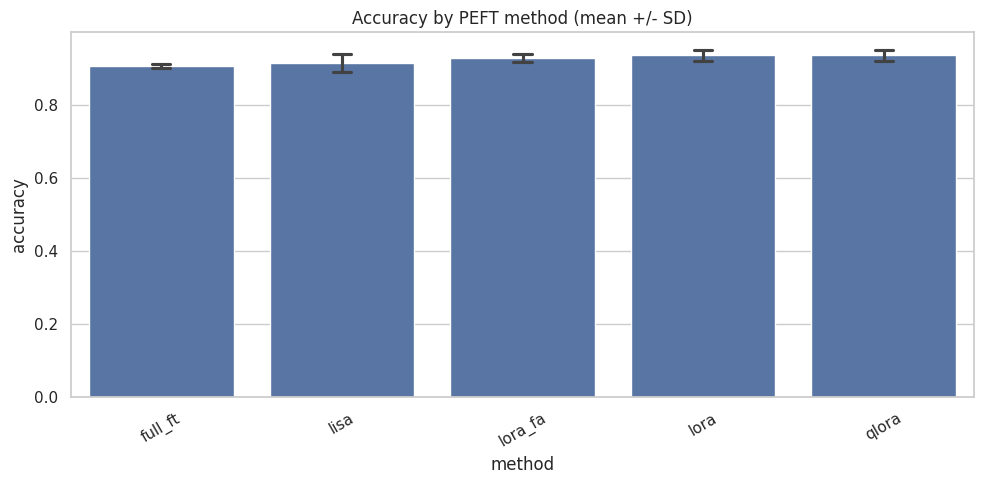

In [14]:
# Bar chart: mean accuracy per method (with std error)
plt.figure(figsize=(10, 5))
order = peft_runs.groupby('method')['accuracy'].mean().sort_values().index
sns.barplot(data=peft_runs, x='method', y='accuracy', order=order,
            ci='sd', capsize=0.1)
plt.title('Accuracy by PEFT method (mean +/- SD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
# Paired comparison: LoRA vs full-FT on the same (backbone, seed)
import re

def _seed(run_id):
    m = re.search(r'seed(\d+)', str(run_id))
    return int(m.group(1)) if m else -1

peft_runs['seed'] = peft_runs['run_id'].apply(_seed)

cols = ['backbone', 'seed', 'accuracy', 'energy_kwh',
        'peak_gpu_memory_gb', 'wall_clock_seconds']

lo = peft_runs.loc[peft_runs['method'] == 'lora', cols]
ft = peft_runs.loc[peft_runs['method'] == 'full_ft', cols]

paired = lo.merge(ft, on=['backbone', 'seed'], suffixes=('_lora', '_full'))

if paired.empty:
    print("No paired (backbone, seed) combinations found between lora and full_ft.")
    print("Backbones with lora:   ", sorted(lo['backbone'].unique()))
    print("Backbones with full_ft:", sorted(ft['backbone'].unique()))
else:
    paired['acc_delta']        = paired['accuracy_lora'] - paired['accuracy_full']
    paired['energy_ratio']     = paired['energy_kwh_lora'] / paired['energy_kwh_full']
    paired['mem_ratio']        = paired['peak_gpu_memory_gb_lora'] / paired['peak_gpu_memory_gb_full']
    paired['time_ratio']       = paired['wall_clock_seconds_lora'] / paired['wall_clock_seconds_full']
    paired['energy_saved_pct'] = (1 - paired['energy_ratio']) * 100
    paired['mem_saved_pct']    = (1 - paired['mem_ratio']) * 100

    print(f"Paired comparisons found: {len(paired)}")
    print(paired[[
        'backbone', 'seed',
        'accuracy_lora', 'accuracy_full', 'acc_delta',
        'energy_kwh_lora', 'energy_kwh_full', 'energy_ratio', 'energy_saved_pct',
        'mem_ratio', 'mem_saved_pct'
    ]].round(6))

Paired comparisons found: 12
   backbone  seed  accuracy_lora  accuracy_full  acc_delta  energy_kwh_lora  energy_kwh_full  energy_ratio  energy_saved_pct  mem_ratio  mem_saved_pct
0      tiny    13         0.9163         0.9117     0.0046         0.001158         0.002394      0.483583         51.641737   0.366952      63.304833
1      tiny    13         0.9163         0.9117     0.0046         0.001158         0.000382      3.027510       -202.750974   0.388366      61.163435
2      tiny  2024         0.9186         0.8991     0.0195         0.001292         0.002409      0.536157         46.384325   0.426523      57.347670
3      tiny  2024         0.9186         0.8991     0.0195         0.001292         0.000383      3.371790       -237.178952   0.454198      54.580153
4      tiny    42         0.9174         0.9048     0.0126         0.001216         0.002380      0.511010         48.899049   0.427282      57.271772
5      tiny    42         0.9174         0.9048     0.0126       

## 7. Efficiency Frontiers — Accuracy vs Energy vs Memory

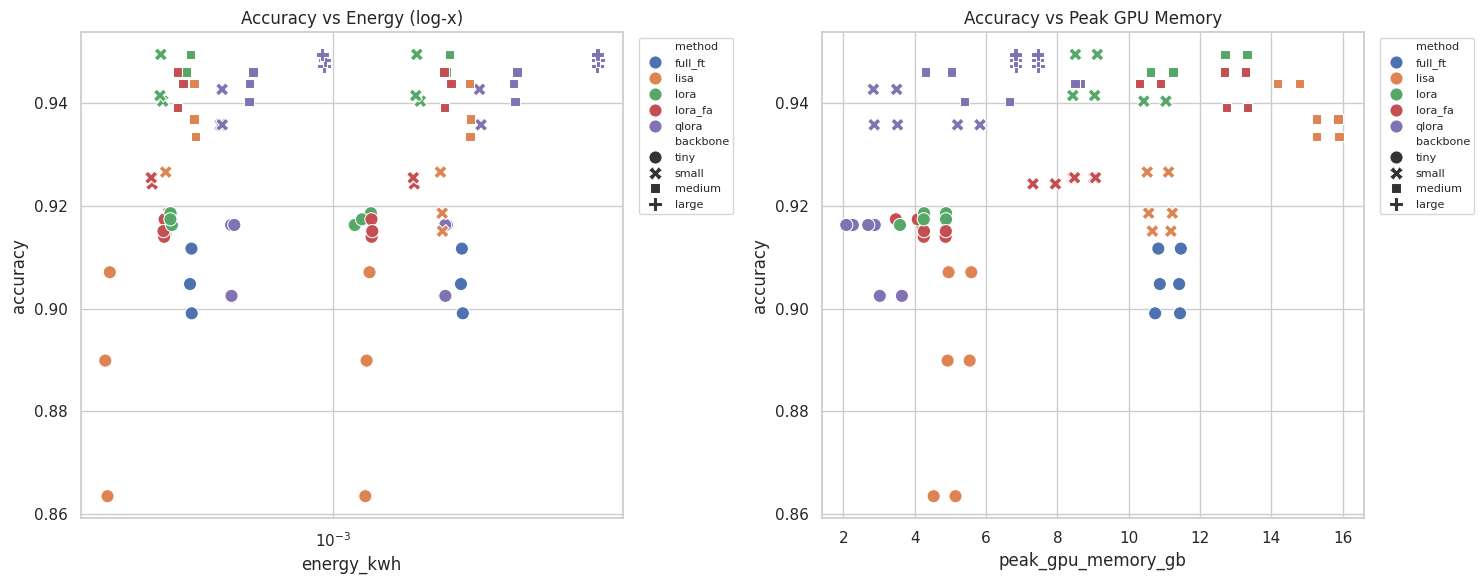

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy vs energy
sns.scatterplot(data=peft_runs, x='energy_kwh', y='accuracy',
                hue='method', style='backbone', s=90, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Accuracy vs Energy (log-x)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Accuracy vs peak memory
sns.scatterplot(data=peft_runs, x='peak_gpu_memory_gb', y='accuracy',
                hue='method', style='backbone', s=90, ax=axes[1])
axes[1].set_title('Accuracy vs Peak GPU Memory')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
# Energy-efficiency ratio: accuracy gained per unit energy
peft_runs['acc_per_energy'] = peft_runs['accuracy'] / peft_runs['energy_kwh']

eff = (peft_runs
       .groupby('method')['acc_per_energy']
       .agg(['mean', 'std', 'count'])
       .sort_values('mean', ascending=False))
eff.round(4)

,mean,std,count
method,,,
lisa,1809.9538,1444.7400,18
lora_fa,1732.5296,1219.3527,18
lora,1696.4481,1155.6418,16
full_ft,1375.6196,1092.8701,6
qlora,959.1949,727.7912,24


## 8. Baseline Predictive Model

We fit a small Random Forest to predict `accuracy` from method / backbone / rank / quant_bits / memory / energy / trainable parameters. GroupKFold is used so that all seeds of the same configuration stay in the same fold — this prevents seed leakage.

In [19]:
features_num = ['params_b', 'rank', 'quant_bits', 'trainable_param_pct',
                'peak_gpu_memory_gb', 'energy_kwh', 'wall_clock_seconds']
features_cat = ['method', 'backbone', 'family']

model_df = peft_runs.dropna(subset=['accuracy']).copy()
X = model_df[features_num + features_cat]
y = model_df['accuracy']
groups = model_df['config_id']  # GroupKFold key

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])

rf = Pipeline([
    ('pre', pre),
    ('rf', RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE,
                                 n_jobs=-1))
])

gkf = GroupKFold(n_splits=min(5, groups.nunique()))
y_pred = np.zeros(len(y))
fold_scores = []

for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
    rf.fit(X.iloc[tr], y.iloc[tr])
    p = rf.predict(X.iloc[te])
    y_pred[te] = p
    r2 = r2_score(y.iloc[te], p)
    mae = mean_absolute_error(y.iloc[te], p)
    fold_scores.append((fold, r2, mae))
    print(f'Fold {fold}: R2={r2:.3f}  MAE={mae:.4f}')

print(f'\nOverall R2  : {r2_score(y, y_pred):.3f}')
print(f'Overall MAE : {mean_absolute_error(y, y_pred):.4f}')

Fold 0: R2=0.880  MAE=0.0051
Fold 1: R2=0.761  MAE=0.0078
Fold 2: R2=0.781  MAE=0.0061
Fold 3: R2=0.940  MAE=0.0029
Fold 4: R2=0.637  MAE=0.0067

Overall R2  : 0.793
Overall MAE : 0.0057


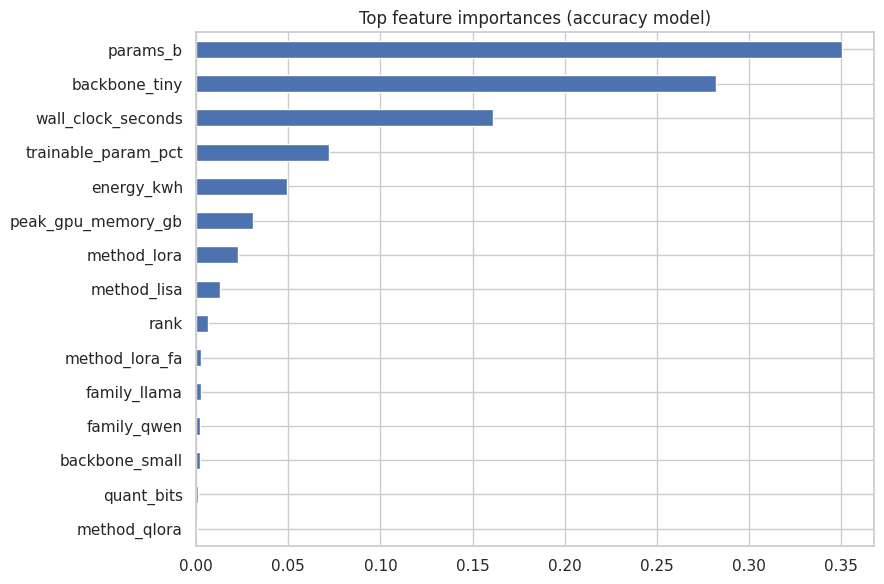

In [20]:
# Feature importances
rf.fit(X, y)
ohe = rf.named_steps['pre'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(features_cat)
feat_names = features_num + list(cat_names)

imp = pd.Series(rf.named_steps['rf'].feature_importances_, index=feat_names)
imp.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(9, 6))
plt.gca().invert_yaxis()
plt.title('Top feature importances (accuracy model)')
plt.tight_layout()
plt.show()

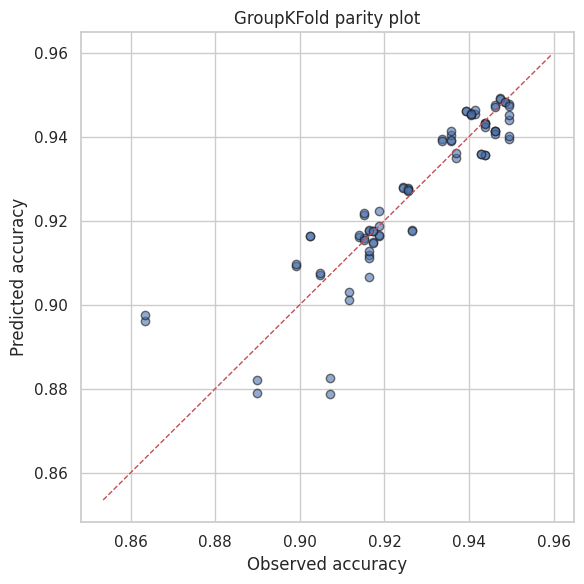

In [21]:
# Parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.6, edgecolor='k')
lims = [min(y.min(), y_pred.min()) - 0.01, max(y.max(), y_pred.max()) + 0.01]
plt.plot(lims, lims, 'r--', lw=1)
plt.xlabel('Observed accuracy')
plt.ylabel('Predicted accuracy')
plt.title('GroupKFold parity plot')
plt.tight_layout()
plt.show()

## 9. Summary & Next Steps

In [22]:
print('DATASET SUMMARY')
print('=' * 60)
print(f'Total rows                        : {len(df)}')
print(f'  Empirical PEFT runs             : {len(peft_runs)}')
print(f'  Scale-reference (inference only): {len(scale_ref)}')
print(f'  Context-only (pretraining)      : {len(context)}')
print(f'Unique methods                    : {peft_runs["method"].nunique()}')
print(f'Unique backbones                  : {peft_runs["backbone"].nunique()}')
print(f'Parameter range (B)               : {peft_runs["params_b"].min()} – {peft_runs["params_b"].max()}')
print(f'Accuracy range                    : {peft_runs["accuracy"].min():.4f} – {peft_runs["accuracy"].max():.4f}')
print(f'Energy range (kWh)                : {peft_runs["energy_kwh"].min():.6f} – {peft_runs["energy_kwh"].max():.6f}')

DATASET SUMMARY
Total rows                        : 477
  Empirical PEFT runs             : 82
  Scale-reference (inference only): 369
  Context-only (pretraining)      : 26
Unique methods                    : 5
Unique backbones                  : 4
Parameter range (B)               : 0.5 – 3.0
Accuracy range                    : 0.8635 – 0.9495
Energy range (kWh)                : 0.000213 – 0.006028


### Suggested next steps

1. **Carbon accounting** — cross-check `carbon_kgco2eq` against `energy_kwh` × regional grid intensity. The dataset currently uses a fixed factor; re-derive per region for a stronger analysis.
2. **Mixed-effects modelling** — treat `config_id` as a random effect to estimate method-level effects while controlling for backbone and family.
3. **Efficiency Pareto front** — explicitly compute the Pareto frontier of (accuracy, energy, memory) to identify dominated configurations.
4. **Scaling laws** — use the `params_b` and `params_x_bits` columns to fit Chinchilla-style scaling curves for PEFT methods.
5. **Uncertainty quantification** — with 3 seeds per configuration, compute 95% confidence intervals and flag statistically indistinguishable pairs.
6. **Cross-dataset validation** — merge with GARF, EfficientLLM, or PEFT-Bench results to test whether the observed efficiency patterns generalise.

Remember to cite the dataset (DOI `10.34740/KAGGLE/DSV/20178095`) in any publication derived from this notebook.